In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
import matplotlib.patheffects as pe

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import compute_AR_from_Q, collect_tracking_R_with_Omega0, tracking_kdtree_with_Omega0, day_plot


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'

dataset = nc.Dataset(fname)

lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))

def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2

dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])

x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [3]:
df_doppio = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_DOPPIO_SEACOFS_26yr_cleaned_and_50m_vert_checked.pkl')
df_doppio = df_doppio[df_doppio.reaches_50m]
df_doppio


,Day,fnumber,nxc,nyc,Cyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,err,Omega0_abs,fname,reaches_50m,ic,jc
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.000007,0.000008,96.456316,-38.462785,63.384028,0.321474,0.000007,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,245,307
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.000015,0.000014,78.042405,-41.260426,50.068171,0.227335,0.000015,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,136,285
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.000004,-0.000007,118.032741,47.992205,74.597458,0.194964,0.000004,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,261,274
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.000016,-0.000013,106.666574,75.106895,69.457705,0.558695,0.000016,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,179,274
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.000010,0.000008,103.327517,-44.066805,65.961546,0.344691,0.000010,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,231,260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367185,10650,10641,852.0,485.0,AE,851.944525,484.893238,0.000014,"[[0.9007012006328585, 0.20548487615413524], [0...",0.000007,0.000006,122.098704,-47.886436,68.779464,0.120315,0.000007,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,248,98
367186,10650,10641,507.0,302.0,CE,507.317516,301.765848,-0.000026,"[[1.0708738864553369, -0.01900508766730702], [...",-0.000013,-0.000009,69.621926,22.250327,39.742296,0.394517,0.000013,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,179,61
367188,10650,10641,860.0,180.0,CE,859.994476,179.913208,-0.000008,"[[0.564056467889216, 0.17870736849564053], [0....",-0.000003,-0.000004,80.423861,12.360816,62.024070,0.086968,0.000003,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,250,36
367189,10650,10641,349.0,158.0,AE,348.663439,158.138527,0.000033,"[[1.3863808771116255, 0.04649055064735413], [0...",0.000016,0.000012,110.552001,-72.997132,43.099927,0.363955,0.000016,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,133,32


,Day,fnumber,nxc,nyc,Cyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,err,Omega0_abs,fname,reaches_50m,ic,jc
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.000007,0.000008,96.456316,-38.462785,63.384028,0.321474,0.000007,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,245,307
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.000015,0.000014,78.042405,-41.260426,50.068171,0.227335,0.000015,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,136,285
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.000004,-0.000007,118.032741,47.992205,74.597458,0.194964,0.000004,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,261,274
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.000016,-0.000013,106.666574,75.106895,69.457705,0.558695,0.000016,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,179,274
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.000010,0.000008,103.327517,-44.066805,65.961546,0.344691,0.000010,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,231,260


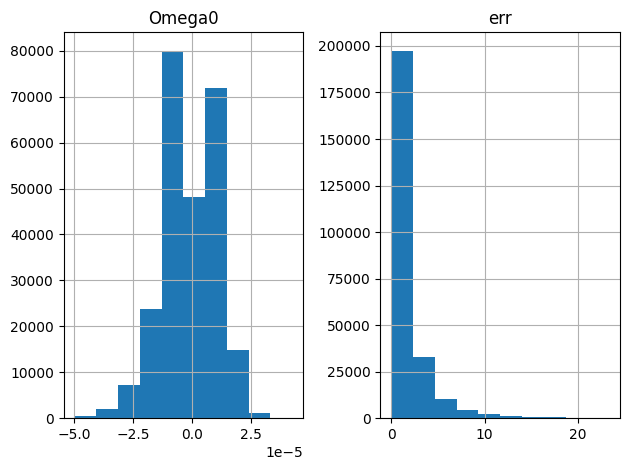

In [4]:
df = df_doppio.copy()
df.hist(['Omega0', 'err'])
plt.tight_layout()
df.head()


Tracking

In [5]:
df_data = df_doppio.copy()
df_data['eddy_idx'] = df_data.groupby('Day').cumcount()
df_data


,Day,fnumber,nxc,nyc,Cyc,xc,yc,w,Q,Omega0,...,Rc,psi0,R,err,Omega0_abs,fname,reaches_50m,ic,jc,eddy_idx
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.000007,...,96.456316,-38.462785,63.384028,0.321474,0.000007,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,245,307,0
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.000015,...,78.042405,-41.260426,50.068171,0.227335,0.000015,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,136,285,1
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.000004,...,118.032741,47.992205,74.597458,0.194964,0.000004,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,261,274,2
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.000016,...,106.666574,75.106895,69.457705,0.558695,0.000016,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,179,274,3
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.000010,...,103.327517,-44.066805,65.961546,0.344691,0.000010,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,231,260,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367185,10650,10641,852.0,485.0,AE,851.944525,484.893238,0.000014,"[[0.9007012006328585, 0.20548487615413524], [0...",0.000007,...,122.098704,-47.886436,68.779464,0.120315,0.000007,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,248,98,13
367186,10650,10641,507.0,302.0,CE,507.317516,301.765848,-0.000026,"[[1.0708738864553369, -0.01900508766730702], [...",-0.000013,...,69.621926,22.250327,39.742296,0.394517,0.000013,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,179,61,14
367188,10650,10641,860.0,180.0,CE,859.994476,179.913208,-0.000008,"[[0.564056467889216, 0.17870736849564053], [0....",-0.000003,...,80.423861,12.360816,62.024070,0.086968,0.000003,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,250,36,15
367189,10650,10641,349.0,158.0,AE,348.663439,158.138527,0.000033,"[[1.3863808771116255, 0.04649055064735413], [0...",0.000016,...,110.552001,-72.997132,43.099927,0.363955,0.000016,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,133,32,16


Optimal R = 1

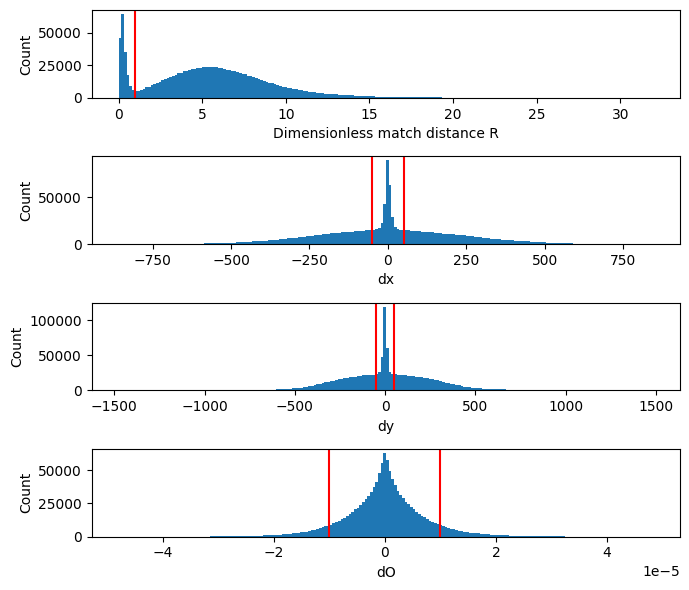

In [12]:
# df = df_data.copy()
# df_R = collect_tracking_R_with_Omega0(
#     df,
#     L_SCALE=50,
#     Omega0_SCALE=1e-5,
#     LOOKBACK=4
# )

# fig, axes = plt.subplots(4, 1, figsize=(7, 6), sharex=False)

# # R
# axes[0].hist(df_R['R'], bins=200)
# axes[0].axvline(1, color='r')
# axes[0].set_xlabel('Dimensionless match distance R')
# axes[0].set_ylabel('Count')

# # dx
# axes[1].hist(df_R['dx'], bins=200)
# axes[1].axvline(-50, color='r')
# axes[1].axvline(50, color='r')
# axes[1].set_xlabel('dx')
# axes[1].set_ylabel('Count')

# # dy
# axes[2].hist(df_R['dy'], bins=200)
# axes[2].axvline(-50, color='r')
# axes[2].axvline(50, color='r')
# axes[2].set_xlabel('dy')
# axes[2].set_ylabel('Count')

# # dw
# axes[3].hist(df_R['dO'], bins=200)
# axes[3].axvline(-1e-5, color='r')
# axes[3].axvline(1e-5, color='r')
# axes[3].set_xlabel('dO')
# axes[3].set_ylabel('Count')

# plt.tight_layout()
# plt.show()


Text(0, 0.5, 'Frequency')

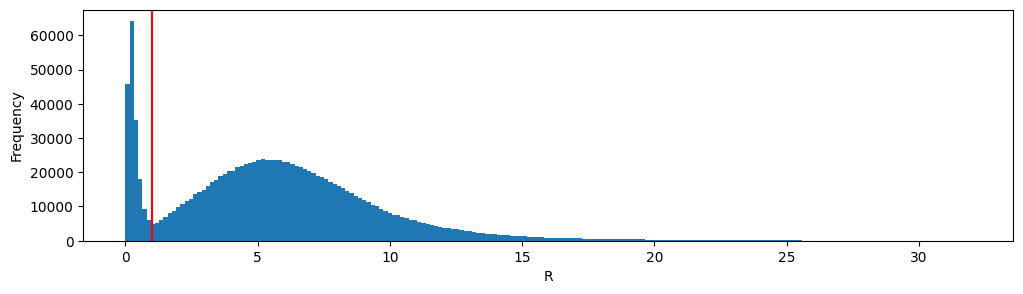

In [13]:
# # R
# fig, ax = plt.subplots(figsize=(12,3))
# ax.hist(df_R['R'], bins=200)
# ax.axvline(1, color='r')
# ax.set_xlabel('R')
# ax.set_ylabel('Frequency')


Tracking

In [6]:
df = df_data.copy()#[df_data.Day <= df_data.Day.min() + 200]

start_ID = np.arange(len(df[df.Day==df.Day.min()]))
next_num = np.max(start_ID) + 1

df_tracked = tracking_kdtree_with_Omega0(
    df,
    start_ID=start_ID,
    next_num=next_num,
    L_SCALE=50,
    Omega0_SCALE=1e-5,
    R_THRESH=1, 
    LOOKBACK=4
)


Day 1600, elapsed: 14.58s
Day 1800, elapsed: 44.63s
Day 2000, elapsed: 67.35s
Day 2200, elapsed: 91.09s
Day 2400, elapsed: 111.70s
Day 2600, elapsed: 138.28s
Day 2800, elapsed: 163.07s
Day 3000, elapsed: 184.66s
Day 3200, elapsed: 208.31s
Day 3400, elapsed: 226.38s
Day 3600, elapsed: 251.34s
Day 3800, elapsed: 271.31s
Day 4000, elapsed: 296.99s
Day 4200, elapsed: 318.40s
Day 4400, elapsed: 343.27s
Day 4600, elapsed: 364.60s
Day 4800, elapsed: 389.26s
Day 5000, elapsed: 415.32s
Day 5200, elapsed: 439.12s
Day 5400, elapsed: 466.36s
Day 5600, elapsed: 487.74s
Day 5800, elapsed: 515.51s
Day 6000, elapsed: 535.84s
Day 6200, elapsed: 566.07s
Day 6400, elapsed: 589.62s
Day 6600, elapsed: 615.25s
Day 6800, elapsed: 643.05s
Day 7000, elapsed: 667.91s
Day 7200, elapsed: 693.40s
Day 7400, elapsed: 714.51s
Day 7600, elapsed: 739.11s
Day 7800, elapsed: 759.25s
Day 8000, elapsed: 789.40s
Day 8200, elapsed: 810.40s
Day 8400, elapsed: 840.04s
Day 8600, elapsed: 860.96s
Day 8800, elapsed: 887.56s
Day 9

In [7]:
df_tracked


,Day,fnumber,nxc,nyc,Cyc,xc,yc,w,Q,Omega0,...,R,err,Omega0_abs,fname,reaches_50m,ic,jc,eddy_idx,Eddy,next_num
0,1462,1461,830.0,1515.0,AE,829.879126,1515.297884,0.000016,"[[0.7054724746035225, -0.17299518294950286], [...",0.000007,...,63.384028,0.321474,0.000007,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,245,307,0,0,42831
1,1462,1461,358.0,1408.0,AE,357.902634,1407.794571,0.000032,"[[1.2525415454561337, -0.37318304544145586], [...",0.000015,...,50.068171,0.227335,0.000015,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,136,285,1,1,42831
2,1462,1461,928.0,1356.0,CE,928.181752,1356.070550,-0.000011,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.000004,...,74.597458,0.194964,0.000004,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,261,274,2,2,42831
3,1462,1461,506.0,1354.0,CE,505.750855,1353.499933,-0.000032,"[[1.0915204469734063, -0.17483272531676586], [...",-0.000016,...,69.457705,0.558695,0.000016,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,179,274,3,3,42831
4,1462,1461,754.0,1285.0,AE,753.849693,1284.689807,0.000022,"[[1.300245004042572, -0.37537759847059776], [-...",0.000010,...,65.961546,0.344691,0.000010,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,231,260,4,4,42831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367185,10650,10641,852.0,485.0,AE,851.944525,484.893238,0.000014,"[[0.9007012006328585, 0.20548487615413524], [0...",0.000007,...,68.779464,0.120315,0.000007,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,248,98,13,42759,42831
367186,10650,10641,507.0,302.0,CE,507.317516,301.765848,-0.000026,"[[1.0708738864553369, -0.01900508766730702], [...",-0.000013,...,39.742296,0.394517,0.000013,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,179,61,14,42739,42831
367188,10650,10641,860.0,180.0,CE,859.994476,179.913208,-0.000008,"[[0.564056467889216, 0.17870736849564053], [0....",-0.000003,...,62.024070,0.086968,0.000003,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,250,36,15,42788,42831
367189,10650,10641,349.0,158.0,AE,348.663439,158.138527,0.000033,"[[1.3863808771116255, 0.04649055064735413], [0...",0.000016,...,43.099927,0.363955,0.000016,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,True,133,32,16,42815,42831


In [8]:
path = '/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tracked_50m_vert_checked.pkl'
df_tracked.to_pickle(path)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


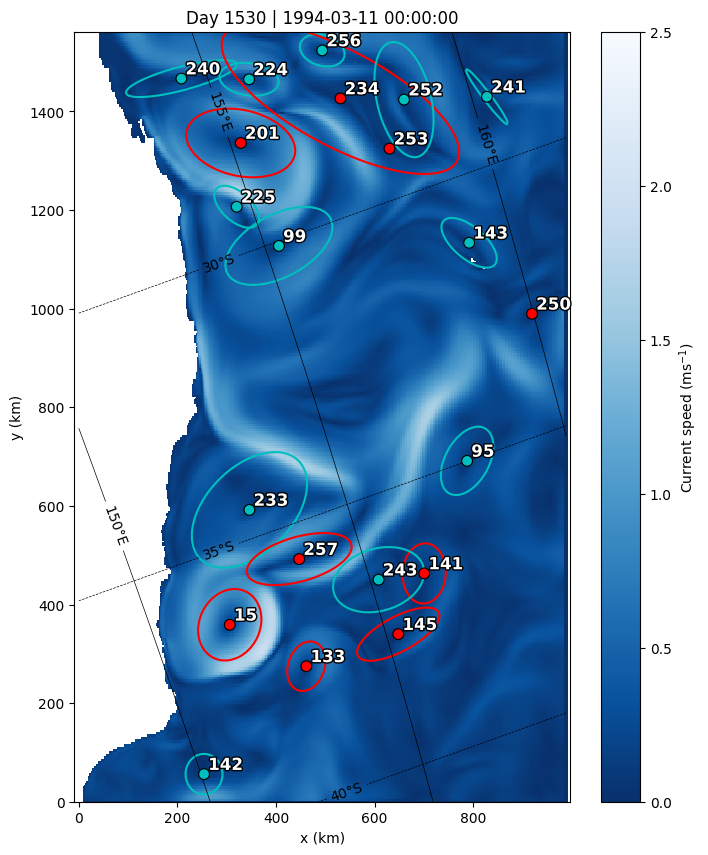

In [9]:
day_plot(1530, df_tracked)
